# Efficient FPT: NumPy vs JAX Implementation Tutorial

This notebook demonstrates and compares the original NumPy/Cython implementation with the new JAX implementation of the efficient first-passage time density algorithms.

**Topics covered:**
1. Setup and imports
2. Single-stage model comparison
3. Multi-stage model (aDDM) comparison
4. Performance benchmarking
5. JAX-specific features: automatic differentiation

For larger or reproducible benchmark runs, use the dedicated scripts in `benchmarks/single_trial_backends.py`, `benchmarks/single_trial_jax_methods.py`, and `benchmarks/batch_gpu_methods.py`. The benchmark cells in this notebook are kept as compact demonstrations.


## 1. Setup and Imports


In [1]:
# Add src to path if running from examples directory
import sys
from pathlib import Path
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
import time

# Original NumPy implementation
from efficient_fpt.single_stage import fptd_single, q_single
from efficient_fpt.quadrature import lgwt_lookup_table

# JAX implementation
import jax
import jax.numpy as jnp
from jax import vmap, grad, jit

from efficient_fpt.jax import (
    fptd_single as fptd_single_jax,
    q_single as q_single_jax,
    compute_heterog_multistage_logfptd,
    set_jax_precision,
)

set_jax_precision(True)

print(f"JAX version: {jax.__version__}")
print(f"Available devices: {jax.devices()}")


JAX version: 0.9.1
Available devices: [CudaDevice(id=0)]


## 2. Single-Stage Model Comparison

The single-stage model computes the first-passage time density for a Brownian motion with drift between two collapsing boundaries.


In [2]:
# Model parameters
mu = 0.5      # Drift rate
sigma = 1.0   # Diffusion coefficient
a1 = 1.5      # Upper boundary intercept
b1 = -0.3     # Upper boundary slope (collapsing)
a2 = -1.5     # Lower boundary intercept
b2 = 0.3      # Lower boundary slope (collapsing)
x0 = 0.0      # Starting position
trunc_num = 10  # Number of series terms
trunc_num_numpy = 10

# Time grid
t_grid = np.linspace(0.1, 4.0, 200)


In [3]:
# Compute FPTD with both implementations
# Upper boundary
fptd_upper_numpy = np.array([
    fptd_single(t, mu, sigma, a1, b1, a2, b2, x0, bdy=1, 
                trunc_num=trunc_num_numpy, adaptive_stopping=False)
    for t in t_grid
])

fptd_upper_jax = np.array([
    float(fptd_single_jax(t, mu, sigma, a1, b1, a2, b2, x0, bdy=1, 
                          trunc_num=trunc_num))
    for t in t_grid
])

# Lower boundary
fptd_lower_numpy = np.array([
    fptd_single(t, mu, sigma, a1, b1, a2, b2, x0, bdy=-1, 
                trunc_num=trunc_num_numpy, adaptive_stopping=False)
    for t in t_grid
])

fptd_lower_jax = np.array([
    float(fptd_single_jax(t, mu, sigma, a1, b1, a2, b2, x0, bdy=-1, 
                          trunc_num=trunc_num))
    for t in t_grid
])

print("Computed FPTD for both implementations.")


Computed FPTD for both implementations.


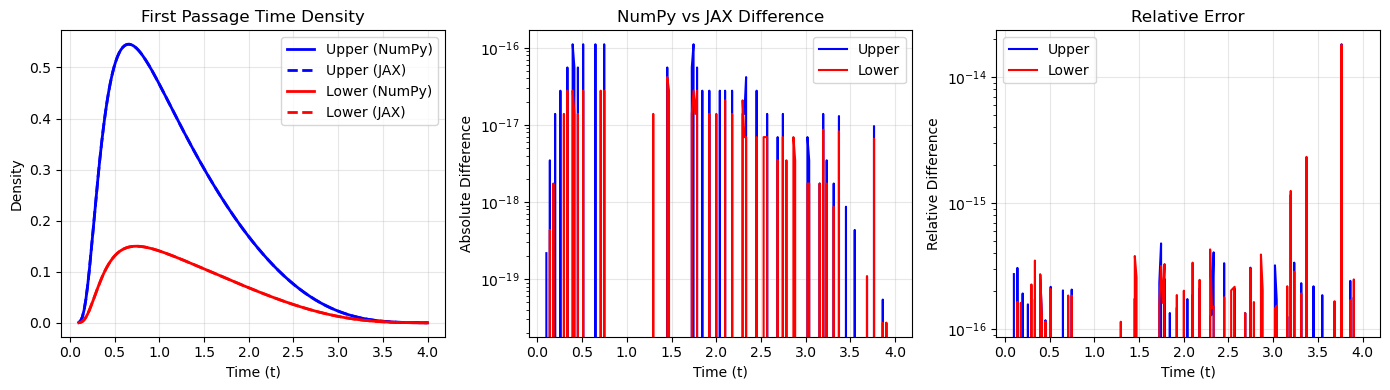

Max absolute difference (upper): 1.11e-16
Max absolute difference (lower): 4.16e-17


In [4]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# FPTD comparison
axes[0].plot(t_grid, fptd_upper_numpy, 'b-', label='Upper (NumPy)', linewidth=2)
axes[0].plot(t_grid, fptd_upper_jax, 'b--', label='Upper (JAX)', linewidth=2)
axes[0].plot(t_grid, fptd_lower_numpy, 'r-', label='Lower (NumPy)', linewidth=2)
axes[0].plot(t_grid, fptd_lower_jax, 'r--', label='Lower (JAX)', linewidth=2)
axes[0].set_xlabel('Time (t)')
axes[0].set_ylabel('Density')
axes[0].set_title('First Passage Time Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Absolute difference
axes[1].semilogy(t_grid, np.abs(fptd_upper_numpy - fptd_upper_jax), 'b-', label='Upper')
axes[1].semilogy(t_grid, np.abs(fptd_lower_numpy - fptd_lower_jax), 'r-', label='Lower')
axes[1].set_xlabel('Time (t)')
axes[1].set_ylabel('Absolute Difference')
axes[1].set_title('NumPy vs JAX Difference')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Relative difference
rel_diff_upper = np.abs(fptd_upper_numpy - fptd_upper_jax) / (np.abs(fptd_upper_numpy) + 1e-10)
rel_diff_lower = np.abs(fptd_lower_numpy - fptd_lower_jax) / (np.abs(fptd_lower_numpy) + 1e-10)
axes[2].semilogy(t_grid, rel_diff_upper, 'b-', label='Upper')
axes[2].semilogy(t_grid, rel_diff_lower, 'r-', label='Lower')
axes[2].set_xlabel('Time (t)')
axes[2].set_ylabel('Relative Difference')
axes[2].set_title('Relative Error')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max absolute difference (upper): {np.max(np.abs(fptd_upper_numpy - fptd_upper_jax)):.2e}")
print(f"Max absolute difference (lower): {np.max(np.abs(fptd_lower_numpy - fptd_lower_jax)):.2e}")


## 3. Multi-Stage Model (aDDM) Comparison

The multi-stage model handles attention-dependent drift diffusion where the drift rate changes at saccade events.


In [5]:
# Multi-stage parameters
sigma = 1.0
a = 1.5      # Initial boundary
b = 0.3      # Collapse rate
x0 = 0.0

# Example: 3 stages with different drift rates
d = 3
mu_array = np.array([0.5, -0.3, 0.2])  # Alternating attention
sacc_array = np.array([0.0, 0.8, 1.6])  # Saccade times

# Pad arrays for JAX (to max_d=5)
max_d = 5
mu_array_padded = np.pad(mu_array, (0, max_d - d))
sacc_array_padded = np.pad(sacc_array, (0, max_d - d))

# Per-stage arrays for compute_heterog_multistage_logfptd
sigma_array_padded = np.full(max_d, sigma)
b1_array_padded = np.full(max_d, -b)   # upper boundary slope (collapsing inward)
b2_array_padded = np.full(max_d, b)    # lower boundary slope (collapsing inward)

# Time grid across the full trial
t_grid_multi = np.linspace(0.01, 4.0, 100)

print(f"Multi-stage model: {d} stages")

Multi-stage model: 3 stages


In [6]:
# Compute multi-stage FPTD using JAX vmap for efficiency
#
# compute_heterog_multistage_logfptd expects d to match the observed RT.
# For a full time-grid curve, we therefore update d as a function of t.
jax_mu = jnp.array(mu_array_padded)
jax_sacc = jnp.array(sacc_array_padded)
jax_sigma_arr = jnp.array(sigma_array_padded)
jax_b1_arr = jnp.array(b1_array_padded)
jax_b2_arr = jnp.array(b2_array_padded)

valid_nodes = sacc_array[:d]
d_grid = np.maximum(1, np.searchsorted(valid_nodes, t_grid_multi, side='right')).astype(np.int32)

batched_jax_upper = vmap(lambda t, d_t: compute_heterog_multistage_logfptd(
    t, 1, x0, a, -a, jax_mu, jax_sacc, jax_sigma_arr, jax_b1_arr, jax_b2_arr,
    d_t, order_mid=30, order_last=30, trunc_num=trunc_num
))

logfptd_multi_jax_upper = batched_jax_upper(jnp.array(t_grid_multi), jnp.array(d_grid))
fptd_multi_jax_upper = jnp.exp(logfptd_multi_jax_upper)

batched_jax_lower = vmap(lambda t, d_t: compute_heterog_multistage_logfptd(
    t, -1, x0, a, -a, jax_mu, jax_sacc, jax_sigma_arr, jax_b1_arr, jax_b2_arr,
    d_t, order_mid=30, order_last=30, trunc_num=trunc_num
))

logfptd_multi_jax_lower = batched_jax_lower(jnp.array(t_grid_multi), jnp.array(d_grid))
fptd_multi_jax_lower = jnp.exp(logfptd_multi_jax_lower)

print("Computed multi-stage log-FPTD with JAX and exponentiated it for plotting.")

Computed multi-stage log-FPTD with JAX and exponentiated it for plotting.


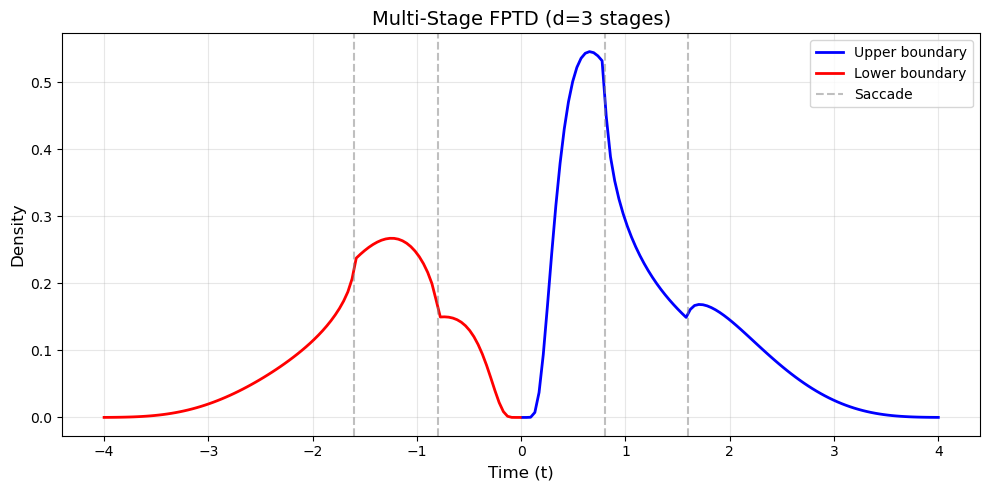

In [7]:
# Visualize multi-stage results
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_grid_multi, np.array(fptd_multi_jax_upper), 'b-', label='Upper boundary', linewidth=2)
ax.plot(-t_grid_multi, np.array(fptd_multi_jax_lower), 'r-', label='Lower boundary', linewidth=2)

# Mark saccade times
for t in sacc_array[1:]:
    ax.axvline(t, color='gray', linestyle='--', alpha=0.5, label='Saccade' if t == sacc_array[1] else '')
    ax.axvline(-t, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Time (t)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Multi-Stage FPTD (d={d} stages)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Performance Benchmarking

Let's compare the performance of different implementations:
- **NumPy (Python loop)**: Sequential, single-threaded
- **Cython + OpenMP**: Parallel across trials using OpenMP threads
- **JAX (vmap + JIT)**: Vectorized with optional GPU acceleration


In [8]:
# Single-Stage Timing: NumPy loop vs JAX vmap
print("=" * 60)
print("SINGLE-STAGE MODEL TIMING")
print("=" * 60)

n_evals = 200
test_times = np.linspace(0.1, 4.0, n_evals)

# NumPy: loop-based
start = time.time()
for _ in range(5):  # 5 repetitions for stable timing
    numpy_results = [fptd_single(t, mu, sigma, a1, b1, a2, b2, x0, bdy=1, trunc_num=trunc_num, adaptive_stopping=False) 
                     for t in test_times]
numpy_loop_time = (time.time() - start) / 5 * 1000

# JAX: vmap (first call includes JIT compilation)
jax_vmap_fn = jit(vmap(lambda t: fptd_single_jax(t, mu, sigma, a1, b1, a2, b2, x0, bdy=1, trunc_num=trunc_num)))
_ = jax_vmap_fn(jnp.array(test_times)).block_until_ready()  # Compile + warmup

start = time.time()
for _ in range(5):
    jax_results = jax_vmap_fn(jnp.array(test_times))
    jax_results.block_until_ready()
jax_vmap_time = (time.time() - start) / 5 * 1000

print(f"Evaluating {n_evals} time points:")
print(f"  NumPy (loop):     {numpy_loop_time:.2f} ms")
print(f"  JAX (vmap + JIT): {jax_vmap_time:.2f} ms")
print(f"  Speedup:          {numpy_loop_time/jax_vmap_time:.1f}x")


SINGLE-STAGE MODEL TIMING


Evaluating 200 time points:
  NumPy (loop):     9.61 ms
  JAX (vmap + JIT): 0.36 ms
  Speedup:          26.6x


### Multi-Stage Timing

This notebook keeps only a compact timing demo. For larger or reproducible
performance studies, prefer the dedicated scripts in
`benchmarks/single_trial_backends.py`, `benchmarks/single_trial_jax_methods.py`,
and `benchmarks/batch_gpu_methods.py`.

For the JAX backend, the relevant compute knob is a fixed `trunc_num`. The
`threshold` and `adaptive_stopping` arguments used below apply to the NumPy and
Cython paths, not to JAX.


In [9]:
# ============================================================
# Lightweight multi-stage timing demo (public APIs only)
# ============================================================
RUN_CYTHON = True
RUN_JAX = True
n_trials = 250
n_repeats = 3
TRUNC_NUM_TIMING = 6

print("=" * 60)
print(f"MULTI-STAGE MODEL TIMING DEMO (d={d} stages, {n_trials} trials)")
print("=" * 60)

np.random.seed(42)
test_rts = np.random.uniform(1.7, 4.0, n_trials).astype(np.float64)
test_choices = np.random.choice([1, -1], n_trials).astype(np.int32)
test_ds = np.full(n_trials, d, dtype=np.int32)
test_mu_arrays = np.tile(mu_array_padded, (n_trials, 1)).astype(np.float64)
test_sacc_arrays = np.tile(sacc_array_padded, (n_trials, 1)).astype(np.float64)

results = {}
jax_values = None
cython_values = None

if RUN_JAX:
    jax_rts = jnp.array(test_rts)
    jax_choices = jnp.array(test_choices)
    jax_ds = jnp.array(test_ds)
    jax_mus = jnp.array(test_mu_arrays)
    jax_saccs = jnp.array(test_sacc_arrays)
    jax_sigs = jnp.tile(jnp.array(sigma_array_padded), (n_trials, 1))
    jax_b1s = jnp.tile(jnp.array(b1_array_padded), (n_trials, 1))
    jax_b2s = jnp.tile(jnp.array(b2_array_padded), (n_trials, 1))

    @jit
    def jax_batch_fn(rts, choices, ds, mus, saccs, sigs, b1s, b2s):
        return vmap(
            lambda rt, ch, dv, mu_arr, sacc_arr, sig_arr, b1_arr, b2_arr: compute_heterog_multistage_logfptd(
                rt,
                ch,
                x0,
                a,
                -a,
                mu_arr,
                sacc_arr,
                sig_arr,
                b1_arr,
                b2_arr,
                dv,
                order_mid=30,
                order_last=30,
                trunc_num=TRUNC_NUM_TIMING,
            )
        )(rts, choices, ds, mus, saccs, sigs, b1s, b2s)

    _ = jax_batch_fn(jax_rts, jax_choices, jax_ds, jax_mus, jax_saccs, jax_sigs, jax_b1s, jax_b2s).block_until_ready()
    start = time.time()
    for _ in range(n_repeats):
        _ = jax_batch_fn(jax_rts, jax_choices, jax_ds, jax_mus, jax_saccs, jax_sigs, jax_b1s, jax_b2s).block_until_ready()
    jax_time = (time.time() - start) / n_repeats * 1000
    jax_values = np.array(
        jax_batch_fn(jax_rts, jax_choices, jax_ds, jax_mus, jax_saccs, jax_sigs, jax_b1s, jax_b2s)
    )
    results['JAX (vmap+JIT)'] = jax_time
    print(f"  JAX (vmap+JIT):       {jax_time:>10.2f} ms  ({jax_time/n_trials:.3f} ms/trial)")

if RUN_CYTHON:
    try:
        from efficient_fpt.cython import compute_heterog_multistage_logfptd as compute_fptd_cy, print_num_threads

        print_num_threads()
        sigma_arr = np.full(d, sigma, dtype=np.float64)
        b1_arr = np.full(d, -b, dtype=np.float64)
        b2_arr = np.full(d, b, dtype=np.float64)

        for i in range(min(10, n_trials)):
            _ = compute_fptd_cy(
                test_rts[i], test_choices[i], x0, a, -a,
                mu_array, sacc_array, sigma_arr, b1_arr, b2_arr, d,
                order_mid=30, order_last=30,
                trunc_num=TRUNC_NUM_TIMING, threshold=1e-20,
            )

        start = time.time()
        for _ in range(n_repeats):
            for i in range(n_trials):
                _ = compute_fptd_cy(
                    test_rts[i], test_choices[i], x0, a, -a,
                    mu_array, sacc_array, sigma_arr, b1_arr, b2_arr, d,
                    order_mid=30, order_last=30,
                    trunc_num=TRUNC_NUM_TIMING, threshold=1e-20,
                )
        cython_time = (time.time() - start) / n_repeats * 1000
        cython_values = np.array([
            compute_fptd_cy(
                test_rts[i], test_choices[i], x0, a, -a,
                mu_array, sacc_array, sigma_arr, b1_arr, b2_arr, d,
                order_mid=30, order_last=30,
                trunc_num=TRUNC_NUM_TIMING, threshold=1e-20,
            )
            for i in range(n_trials)
        ])
        results['Cython'] = cython_time
        print(f"  Cython (per-trial):   {cython_time:>10.2f} ms  ({cython_time/n_trials:.3f} ms/trial)")
    except ImportError as e:
        print(f"  Cython not available: {e}")

if jax_values is not None and cython_values is not None:
    abs_diff = np.abs(jax_values - cython_values)
    print()
    print("Value comparison on the same multi-stage trials:")
    print(f"  max |JAX - Cython|:  {abs_diff.max():.3e}")
    print(f"  mean |JAX - Cython|: {abs_diff.mean():.3e}")
    print("  first 5 trial values:")
    for i in range(5):
        print(
            f"    trial {i:>2}: JAX={jax_values[i]:.6e}, "
            f"Cython={cython_values[i]:.6e}, |Δ|={abs_diff[i]:.3e}"
        )
    print(f"  allclose? {np.allclose(jax_values, cython_values, rtol=1e-4, atol=1e-6)}")


MULTI-STAGE MODEL TIMING DEMO (d=3 stages, 250 trials)
  JAX (vmap+JIT):             2.22 ms  (0.009 ms/trial)
Number of available threads: 32
  Cython (per-trial):        39.83 ms  (0.159 ms/trial)

Value comparison on the same multi-stage trials:
  max |JAX - Cython|:  7.105e-15
  mean |JAX - Cython|: 4.379e-16
  first 5 trial values:
    trial  0: JAX=-2.681527e+00, Cython=-2.681527e+00, |Δ|=4.441e-16
    trial  1: JAX=-8.366948e+00, Cython=-8.366948e+00, |Δ|=1.776e-15
    trial  2: JAX=-5.024082e+00, Cython=-5.024082e+00, |Δ|=0.000e+00
    trial  3: JAX=-4.124720e+00, Cython=-4.124720e+00, |Δ|=0.000e+00
    trial  4: JAX=-1.982365e+00, Cython=-1.982365e+00, |Δ|=4.441e-16
  allclose? True


### Scalability: Batch Size vs Time


Batch size scaling (JAX demo):
Batch      JAX (ms)    
------------------------


10         0.39        
50         0.68        
100        1.11        
250        2.24        
500        4.55        


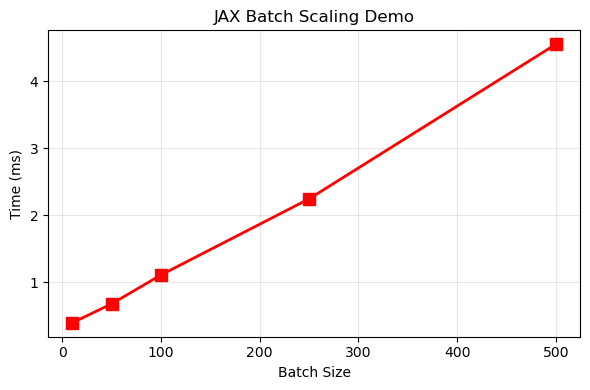

In [10]:
# ============================================================
# Lightweight JAX scaling demo
# ============================================================
TRUNC_NUM_TIMING = 6
batch_sizes = [10, 50, 100, 250, 500]

print("Batch size scaling (JAX demo):")
print(f"{'Batch':<10} {'JAX (ms)':<12}")
print("-" * 24)

jax_times = []

for batch_size in batch_sizes:
    np.random.seed(42)
    test_rts_batch = np.random.uniform(1.7, 4.0, batch_size).astype(np.float64)
    test_choices_batch = np.random.choice([1, -1], batch_size).astype(np.int32)
    test_ds_batch = np.full(batch_size, d, dtype=np.int32)
    test_mu_batch = np.tile(mu_array_padded, (batch_size, 1)).astype(np.float64)
    test_sacc_batch = np.tile(sacc_array_padded, (batch_size, 1)).astype(np.float64)

    jax_rts = jnp.array(test_rts_batch)
    jax_choices = jnp.array(test_choices_batch)
    jax_ds = jnp.array(test_ds_batch)
    jax_mus = jnp.array(test_mu_batch)
    jax_saccs = jnp.array(test_sacc_batch)
    jax_sigs = jnp.tile(jnp.array(sigma_array_padded), (batch_size, 1))
    jax_b1s = jnp.tile(jnp.array(b1_array_padded), (batch_size, 1))
    jax_b2s = jnp.tile(jnp.array(b2_array_padded), (batch_size, 1))

    @jit
    def jax_batch_fn(rts, choices, ds, mus, saccs, sigs, b1s, b2s):
        return vmap(
            lambda rt, ch, dv, mu_arr, sacc_arr, sig_arr, b1_arr, b2_arr: compute_heterog_multistage_logfptd(
                rt,
                ch,
                x0,
                a,
                -a,
                mu_arr,
                sacc_arr,
                sig_arr,
                b1_arr,
                b2_arr,
                dv,
                order_mid=30,
                order_last=30,
                trunc_num=TRUNC_NUM_TIMING,
            )
        )(rts, choices, ds, mus, saccs, sigs, b1s, b2s)

    _ = jax_batch_fn(jax_rts, jax_choices, jax_ds, jax_mus, jax_saccs, jax_sigs, jax_b1s, jax_b2s).block_until_ready()
    start = time.time()
    _ = jax_batch_fn(jax_rts, jax_choices, jax_ds, jax_mus, jax_saccs, jax_sigs, jax_b1s, jax_b2s).block_until_ready()
    jax_time = (time.time() - start) * 1000
    jax_times.append(jax_time)
    print(f"{batch_size:<10} {jax_time:<12.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(batch_sizes, jax_times, 'rs-', linewidth=2, markersize=8)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Time (ms)')
ax.set_title('JAX Batch Scaling Demo')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. JAX-Specific Feature: Automatic Differentiation

A key advantage of JAX is automatic differentiation, enabling gradient-based optimization for model parameters.

### The Padding Problem and Safe Padding Solution

When batching trials with different numbers of stages (`d`), we pad arrays to a common `max_d`:

```
Trial 1 (d=3): mu = [0.5, -0.3, 0.2]      → padded: [0.5, -0.3, 0.2, 0.0, 0.0]
               sacc = [0.0, 0.8, 1.6]     → padded: [0.0, 0.8, 1.6, 0.0, 0.0]
```

**The Problem**: Zero-padded `sacc_array` causes `T_curr = 0.0 - 0.0 = 0`, leading to division by zero. Even though these invalid stages are masked out in the forward pass, JAX evaluates **both branches** of `jnp.where` during gradient computation, propagating NaN.

**The Solution**: **Safe padding** extends `sacc_array` with increasing times:

```
Zero-padded: [0.0, 0.8, 1.6, 0.0, 0.0]  → T_curr = 0.0 for padded stages → NaN!
Safe-padded: [0.0, 0.8, 1.6, 2.4, 3.2]  → T_curr = 0.8 for padded stages → valid!
```

The invalid stages now compute valid (but ignored) numbers, so gradients remain finite.


In [11]:
# First, let's see how zero-padded stage arrays are interpreted
print("=" * 60)
print("ZERO-PADDED STAGE ARRAY DEMONSTRATION")
print("=" * 60)

d_demo = 3
max_d_demo = 5
sacc_zero_padded = jnp.array([0.0, 0.8, 1.6, 0.0, 0.0])
valid_transition_mask = jnp.arange(max_d_demo - 1) < (d_demo - 1)
raw_stage_durations = jnp.diff(sacc_zero_padded)
active_stage_durations = raw_stage_durations[: d_demo - 1]

print(f"Zero-padded sacc_array: {sacc_zero_padded}")
print(f"Valid transition mask:  {valid_transition_mask}")
print(f"Raw diff:              {raw_stage_durations}")
print(f"Active durations:      {active_stage_durations}")
print()
print("The JAX multistage kernels use d to decide which stage transitions are active.")
print("Inactive padded slots stay in the fixed-shape arrays for batching, but they are not part of the physical trial.")


ZERO-PADDED STAGE ARRAY DEMONSTRATION
Zero-padded sacc_array: [0.  0.8 1.6 0.  0. ]
Valid transition mask:  [ True  True False False]
Raw diff:              [ 0.8  0.8 -1.6  0. ]
Active durations:      [0.8 0.8]

The JAX multistage kernels use d to decide which stage transitions are active.
Inactive padded slots stay in the fixed-shape arrays for batching, but they are not part of the physical trial.


### Single-Stage Gradients


In [12]:
# Define a differentiable likelihood function using single-stage model
def single_stage_likelihood(sigma_param, a_param, b_param, t_obs=1.5, trunc_num=trunc_num):
    """Compute likelihood for single-stage model (symmetric boundaries)."""
    a1_param = a_param
    b1_param = -b_param
    a2_param = -a_param
    b2_param = b_param
    return fptd_single_jax(
        t_obs,
        mu,
        sigma_param,
        a1_param,
        b1_param,
        a2_param,
        b2_param,
        x0,
        bdy=1,
        trunc_num=trunc_num,
    )


def central_difference_3param(fn, sigma_param, a_param, b_param, argnum, *extra_args, eps=1e-4):
    params_plus = [sigma_param, a_param, b_param]
    params_minus = [sigma_param, a_param, b_param]
    params_plus[argnum] += eps
    params_minus[argnum] -= eps
    f_plus = float(fn(*params_plus, *extra_args))
    f_minus = float(fn(*params_minus, *extra_args))
    return (f_plus - f_minus) / (2 * eps)

# Compute gradients with respect to parameters
grad_sigma = grad(single_stage_likelihood, argnums=0)
grad_a = grad(single_stage_likelihood, argnums=1)
grad_b = grad(single_stage_likelihood, argnums=2)

# Evaluate at test parameters
sigma_test, a_test, b_test = 1.0, 1.5, 0.3
t_obs = 1.5

likelihood_value = single_stage_likelihood(sigma_test, a_test, b_test, t_obs)
grad_sigma_value = grad_sigma(sigma_test, a_test, b_test, t_obs)
grad_a_value = grad_a(sigma_test, a_test, b_test, t_obs)
grad_b_value = grad_b(sigma_test, a_test, b_test, t_obs)
fd_sigma_value = central_difference_3param(single_stage_likelihood, sigma_test, a_test, b_test, 0, t_obs)
fd_a_value = central_difference_3param(single_stage_likelihood, sigma_test, a_test, b_test, 1, t_obs)
fd_b_value = central_difference_3param(single_stage_likelihood, sigma_test, a_test, b_test, 2, t_obs)

print("=" * 60)
print("AUTOMATIC DIFFERENTIATION (Single-Stage Model)")
print("=" * 60)
print(f"Parameters: σ={sigma_test}, a={a_test}, b={b_test}")
print(f"Observation: t={t_obs}, upper boundary")
print()
print(f"Likelihood:  L = {float(likelihood_value):.6f}")
print("Gradients (autodiff vs finite difference):")
print(f"  ∂L/∂σ = {float(grad_sigma_value):.6f}   |   FD ≈ {fd_sigma_value:.6f}   |   |Δ|={abs(float(grad_sigma_value) - fd_sigma_value):.3e}")
print(f"  ∂L/∂a = {float(grad_a_value):.6f}   |   FD ≈ {fd_a_value:.6f}   |   |Δ|={abs(float(grad_a_value) - fd_a_value):.3e}")
print(f"  ∂L/∂b = {float(grad_b_value):.6f}   |   FD ≈ {fd_b_value:.6f}   |   |Δ|={abs(float(grad_b_value) - fd_b_value):.3e}")


AUTOMATIC DIFFERENTIATION (Single-Stage Model)
Parameters: σ=1.0, a=1.5, b=0.3
Observation: t=1.5, upper boundary

Likelihood:  L = 0.301893
Gradients (autodiff vs finite difference):
  ∂L/∂σ = -0.403098   |   FD ≈ -0.403098   |   |Δ|=1.516e-09
  ∂L/∂a = 0.237475   |   FD ≈ 0.237475   |   |Δ|=2.590e-09
  ∂L/∂b = 0.005340   |   FD ≈ 0.005340   |   |Δ|=5.898e-09


### Multi-Stage Log-FPTD Gradients (with Safe Padding)

The key innovation is that `compute_heterog_multistage_logfptd` internally applies safe padding, so you can pass zero-padded arrays and still compute gradients of the log-FPTD correctly!


In [13]:
# Multi-stage gradients with zero-padded arrays (active stages selected internally)
TRUNC_NUM = TRUNC_NUM_TIMING

def multi_stage_logfptd(sigma_param, a_param, b_param, t_obs=2.5, choice_obs=1, trunc_num=TRUNC_NUM):
    """Compute log-FPTD for a multi-stage model with zero-padded arrays."""
    b1_arr = jnp.full(max_d, -b_param)
    b2_arr = jnp.full(max_d, b_param)
    sigma_arr = jnp.full(max_d, sigma_param)
    return compute_heterog_multistage_logfptd(
        t_obs, choice_obs, x0, a_param, -a_param,
        jnp.array(mu_array_padded), jnp.array(sacc_array_padded),
        sigma_arr, b1_arr, b2_arr,
        d, order_mid=30, order_last=30, trunc_num=trunc_num,
    )

# Compute gradients for multi-stage model
grad_sigma_multi = grad(multi_stage_logfptd, argnums=0)
grad_a_multi = grad(multi_stage_logfptd, argnums=1)
grad_b_multi = grad(multi_stage_logfptd, argnums=2)

sigma_test, a_test, b_test = 1.0, 1.5, 0.3
t_obs_multi = 2.5
choice_obs = 1

logfptd_multi = multi_stage_logfptd(sigma_test, a_test, b_test, t_obs_multi, choice_obs)
grad_sigma_multi_val = grad_sigma_multi(sigma_test, a_test, b_test, t_obs_multi, choice_obs)
grad_a_multi_val = grad_a_multi(sigma_test, a_test, b_test, t_obs_multi, choice_obs)
grad_b_multi_val = grad_b_multi(sigma_test, a_test, b_test, t_obs_multi, choice_obs)
fd_sigma_multi_val = central_difference_3param(multi_stage_logfptd, sigma_test, a_test, b_test, 0, t_obs_multi, choice_obs)
fd_a_multi_val = central_difference_3param(multi_stage_logfptd, sigma_test, a_test, b_test, 1, t_obs_multi, choice_obs)
fd_b_multi_val = central_difference_3param(multi_stage_logfptd, sigma_test, a_test, b_test, 2, t_obs_multi, choice_obs)

print("=" * 60)
print("AUTOMATIC DIFFERENTIATION (Multi-Stage Log-FPTD)")
print("=" * 60)
print(f"Parameters: sigma={sigma_test}, a={a_test}, b={b_test}")
print(f"Model: d={d} stages, mu={mu_array}, sacc={sacc_array}")
print(f"Observation: t={t_obs_multi}, choice={'upper' if choice_obs == 1 else 'lower'}")
print()
print(f"Log-FPTD:  log f = {float(logfptd_multi):.6f}")
print("Gradients (autodiff vs finite difference):")
print(f"  dL/dsigma = {float(grad_sigma_multi_val):.6f}   |   FD ≈ {fd_sigma_multi_val:.6f}   |   |Δ|={abs(float(grad_sigma_multi_val) - fd_sigma_multi_val):.3e}")
print(f"  dL/da = {float(grad_a_multi_val):.6f}   |   FD ≈ {fd_a_multi_val:.6f}   |   |Δ|={abs(float(grad_a_multi_val) - fd_a_multi_val):.3e}")
print(f"  dL/db = {float(grad_b_multi_val):.6f}   |   FD ≈ {fd_b_multi_val:.6f}   |   |Δ|={abs(float(grad_b_multi_val) - fd_b_multi_val):.3e}")


AUTOMATIC DIFFERENTIATION (Multi-Stage Log-FPTD)
Parameters: sigma=1.0, a=1.5, b=0.3
Model: d=3 stages, mu=[ 0.5 -0.3  0.2], sacc=[0.  0.8 1.6]
Observation: t=2.5, choice=upper

Log-FPTD:  log f = -2.574315
Gradients (autodiff vs finite difference):
  dL/dsigma = -3.924699   |   FD ≈ -3.924699   |   |Δ|=9.796e-10
  dL/da = 3.552331   |   FD ≈ 3.552331   |   |Δ|=1.086e-07
  dL/db = -4.639978   |   FD ≈ -4.639979   |   |Δ|=8.212e-07


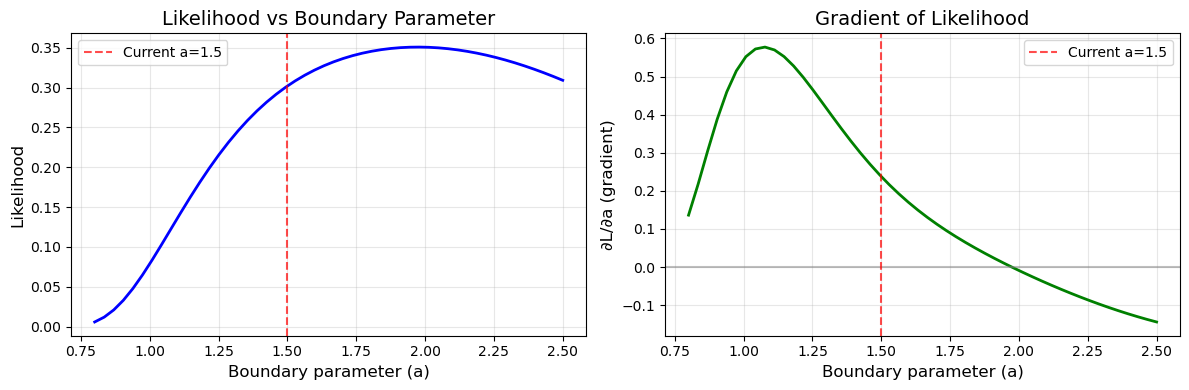

The gradient tells us which direction to move 'a' to increase the likelihood.


In [14]:
# Visualize likelihood surface and gradients
param_grid = np.linspace(0.8, 2.5, 50)

# Likelihood vs boundary parameter 'a'
likelihoods_vs_a = [float(single_stage_likelihood(sigma_test, a_i, b_test, t_obs)) 
                    for a_i in param_grid]
gradients_vs_a = [float(grad_a(sigma_test, a_i, b_test, t_obs)) 
                  for a_i in param_grid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Likelihood curve
axes[0].plot(param_grid, likelihoods_vs_a, 'b-', linewidth=2)
axes[0].axvline(a_test, color='r', linestyle='--', alpha=0.7, label=f'Current a={a_test}')
axes[0].set_xlabel('Boundary parameter (a)', fontsize=12)
axes[0].set_ylabel('Likelihood', fontsize=12)
axes[0].set_title('Likelihood vs Boundary Parameter', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gradient curve
axes[1].plot(param_grid, gradients_vs_a, 'g-', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.5)
axes[1].axvline(a_test, color='r', linestyle='--', alpha=0.7, label=f'Current a={a_test}')
axes[1].set_xlabel('Boundary parameter (a)', fontsize=12)
axes[1].set_ylabel('∂L/∂a (gradient)', fontsize=12)
axes[1].set_title('Gradient of Likelihood', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The gradient tells us which direction to move 'a' to increase the likelihood.")


## Summary

**Key takeaways:**

1. **Numerical equivalence**: The JAX implementation produces numerically equivalent results to the NumPy implementation within floating-point tolerance.

2. **Public JAX APIs**: The recommended JAX entrypoints are the public functions in `efficient_fpt.jax`, which already handle batching, JIT compilation, and differentiation-friendly execution.

3. **Performance demos vs benchmark suite**: The timing cells here are lightweight illustrations, but they now also report JAX-vs-Cython value agreement for the same multistage trials. For more serious comparisons, use the dedicated scripts in `benchmarks/`.

4. **Zero-padded stage arrays**: Multi-stage JAX calls accept zero-padded arrays together with `d`, and the implementation uses `d` to identify which stage transitions are active.

5. **Automatic differentiation**: JAX enables gradients of single-stage and multi-stage likelihoods, and the tutorial now checks those gradients against central finite differences so the derivative values are not just taken on faith.
